In [1]:
import yaml
 
try:
    with open("../config.yaml", "r") as file:
        config = yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

In [2]:
import pandas as pd

df = pd.read_csv(config['input_data']['file'])
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [3]:
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

In [4]:
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,0.238667,0,0,4.492838,1,0,0,0,0,1
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,8.687480,0,1,9.204952,0,0,0,0,0,1
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,1.972137,0,0,5.036334,0,0,0,0,0,1
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,...,5.173891,0,0,3.785399,0,0,0,0,1,1


In [6]:
df.dtypes

Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
ADL                          float64
C

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

In [6]:
selected_features = [
    'MemoryComplaints',
    'BehavioralProblems',
    'FunctionalAssessment',
    'ADL',
    'MMSE'
]

X = df[selected_features]
y = df['Diagnosis']  # 0/1 for Alzheimer's

Accuracy: 0.9465116279069767

Confusion Matrix:
 [[268  10]
 [ 13 139]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       278
           1       0.93      0.91      0.92       152

    accuracy                           0.95       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



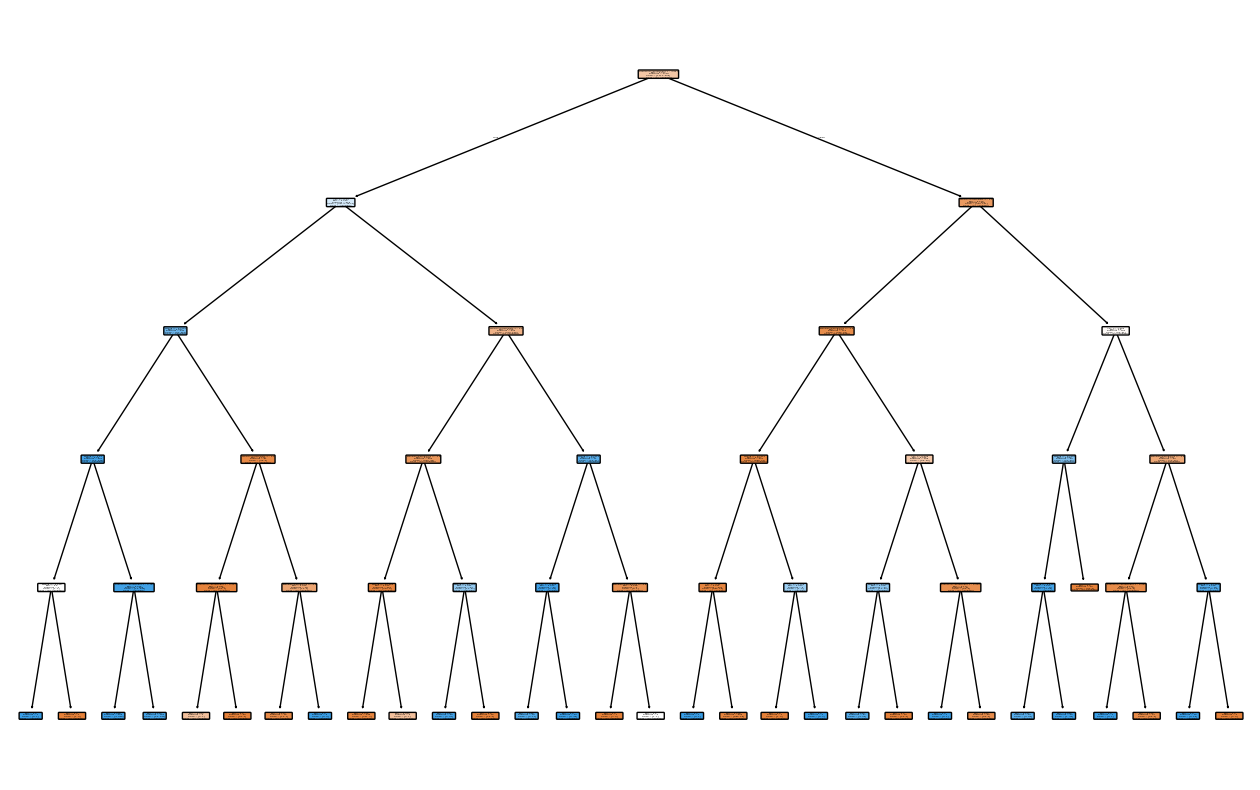

In [7]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Decision Tree
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)  # max_depth optional
dtree.fit(X_train, y_train)

# Make predictions
y_pred = dtree.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: Visualize the Decision Tree
plt.figure(figsize=(16,10))
tree.plot_tree(
    dtree, 
    feature_names=selected_features, 
    class_names=['No Alzheimer', 'Alzheimer'], 
    filled=True, 
    rounded=True
)
plt.show()

In [8]:
#check feature importance via:

importances = pd.DataFrame({
    'Feature': selected_features,
    'Importance': dtree.feature_importances_
})
print(importances.sort_values(by='Importance', ascending=False))

                Feature  Importance
4                  MMSE    0.280763
3                   ADL    0.230345
2  FunctionalAssessment    0.203791
0      MemoryComplaints    0.162402
1    BehavioralProblems    0.122699


In [9]:

# library imports

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
)


sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


# Show DataFrame with 5 features you listed


print("Shape:", df.shape)
print("Columns:", list(df.columns))


selected_features = [
    'MemoryComplaints',
    'BehavioralProblems',
    'FunctionalAssessment',
    'ADL',
    'MMSE'
]

# Defined X and y from df

X = df[selected_features].copy()
y = df['Diagnosis'].astype(int).values  # 0/1 for Alzheimer's

# Quick sanity checks
print("\nClass counts:", pd.Series(y).value_counts().to_dict())
print("Selected features head:")
display(X.head())

# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Shape: (2149, 33)
Columns: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']

Class counts: {0: 1389, 1: 760}
Selected features head:


,MemoryComplaints,BehavioralProblems,FunctionalAssessment,ADL,MMSE
0,0,0,6.518877,1.725883,21.463532
1,0,0,7.118696,2.592424,20.613267
2,0,0,5.895077,7.119548,7.356249
3,0,1,8.965106,6.481226,13.991127
4,0,0,6.045039,0.014691,13.517609


In [10]:


# 3) Train a Decision Tree with hyperparameters. Chose the best with 5-fold CV using recall

param_grid = {
    "max_depth": [3, 5, 7, 9],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]  # handles imbalance
}

base_tree = DecisionTreeClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring="recall",         # use "f1" if for balance
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

dtree = grid.best_estimator_
print("\nBest params:", grid.best_params_)
print("Best CV recall:", round(grid.best_score_, 3))



Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV recall: 0.929


In [11]:


# Default is 0.5. Chose a threshold on train data to recall.

y_train_prob = dtree.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_prob)

target_recall = 0.90  # change if you want different sensitivity
idxs = np.where(recalls >= target_recall)[0]
if len(idxs) > 0:
    idx = idxs[-1]
    chosen_threshold = thresholds[max(idx-1, 0)] if idx < len(thresholds) else 0.5
else:
    chosen_threshold = 0.5

print("Chosen threshold:", round(chosen_threshold, 3), "(target recall:", target_recall, ")")


Chosen threshold: 0.785 (target recall: 0.9 )


In [12]:
# Evaluate on the test set

y_test_prob = dtree.predict_proba(X_test)[:, 1]
y_pred_default = (y_test_prob >= 0.5).astype(int)
y_pred_chosen  = (y_test_prob >= chosen_threshold).astype(int)

print("\nResults with default threshold (0.5):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_default), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default, digits=3))

print("\nResults with chosen threshold:", round(chosen_threshold, 3))
print("Accuracy:", round(accuracy_score(y_test, y_pred_chosen), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_chosen))
print(classification_report(y_test, y_pred_chosen, digits=3))

auc_score = roc_auc_score(y_test, y_test_prob)
print("ROC AUC:", round(auc_score, 3))



Results with default threshold (0.5):
Accuracy: 0.93
Confusion matrix:
 [[261  17]
 [ 13 139]]
              precision    recall  f1-score   support

           0      0.953     0.939     0.946       278
           1      0.891     0.914     0.903       152

    accuracy                          0.930       430
   macro avg      0.922     0.927     0.924       430
weighted avg      0.931     0.930     0.930       430


Results with chosen threshold: 0.785
Accuracy: 0.94
Confusion matrix:
 [[266  12]
 [ 14 138]]
              precision    recall  f1-score   support

           0      0.950     0.957     0.953       278
           1      0.920     0.908     0.914       152

    accuracy                          0.940       430
   macro avg      0.935     0.932     0.934       430
weighted avg      0.939     0.940     0.939       430

ROC AUC: 0.94


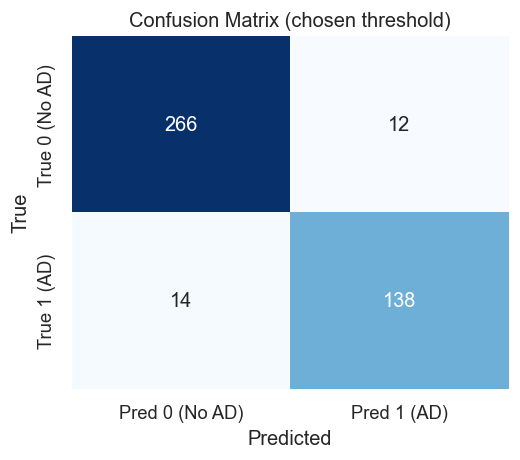

In [13]:

# Confusion matrix heatmap (chosen threshold)

cm = confusion_matrix(y_test, y_pred_chosen)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0 (No AD)", "Pred 1 (AD)"],
            yticklabels=["True 0 (No AD)", "True 1 (AD)"])
plt.title("Confusion Matrix (chosen threshold)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


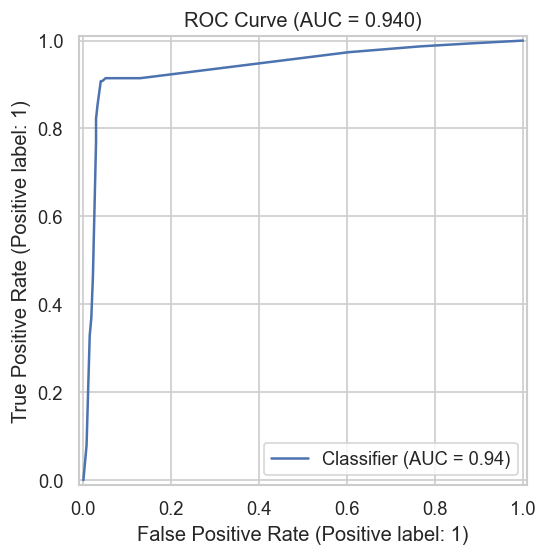

In [14]:

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.tight_layout()
plt.show()


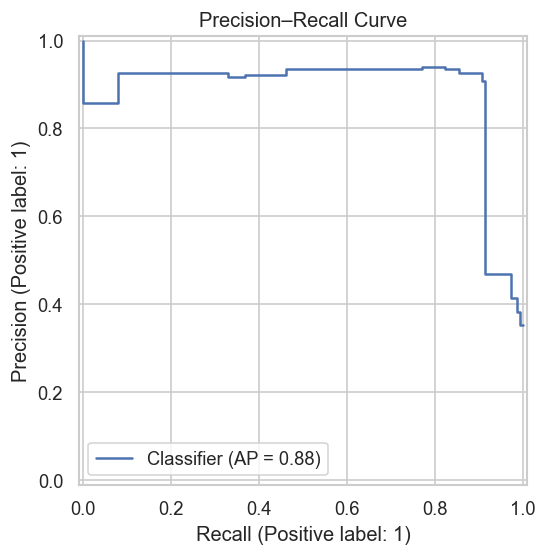

In [15]:

# Precision–Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_prob)
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.show()



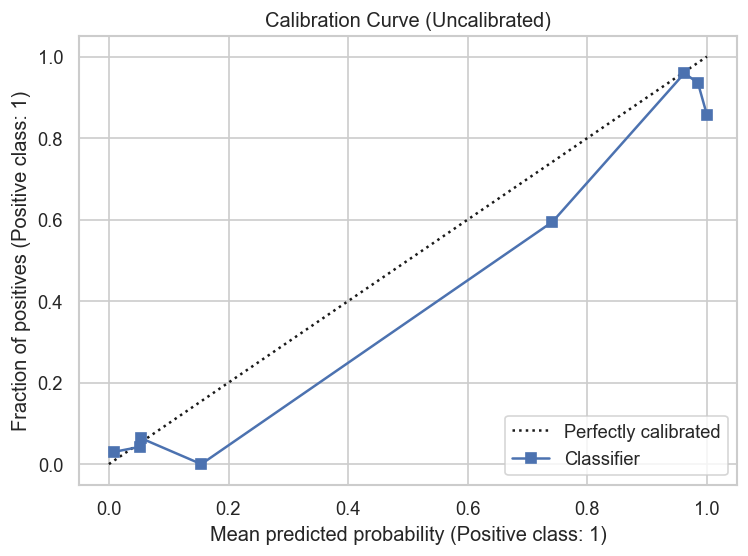

In [16]:
# Calibration (uncalibrated)
CalibrationDisplay.from_predictions(y_test, y_test_prob, n_bins=10, strategy="quantile")
plt.title("Calibration Curve (Uncalibrated)")
plt.tight_layout()
plt.show()




Feature importances:


,Feature,Importance
2,FunctionalAssessment,0.228244
4,MMSE,0.206851
3,ADL,0.194906
0,MemoryComplaints,0.188377
1,BehavioralProblems,0.181622


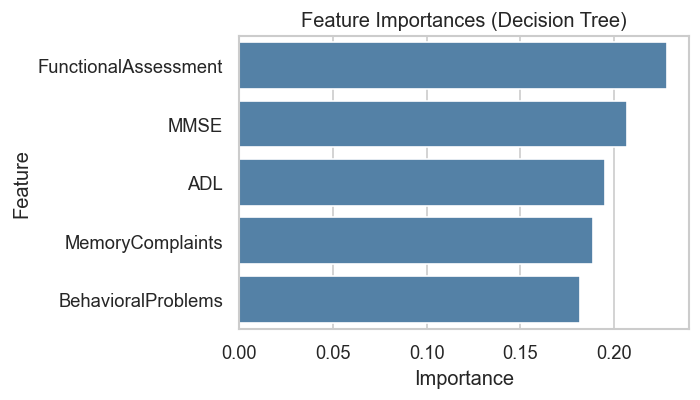

In [17]:

# Feature importances

importances = pd.DataFrame({
    "Feature": selected_features,
    "Importance": dtree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature importances:")
display(importances)

plt.figure(figsize=(6,3.5))
sns.barplot(data=importances, x="Importance", y="Feature", color="steelblue")
plt.title("Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()


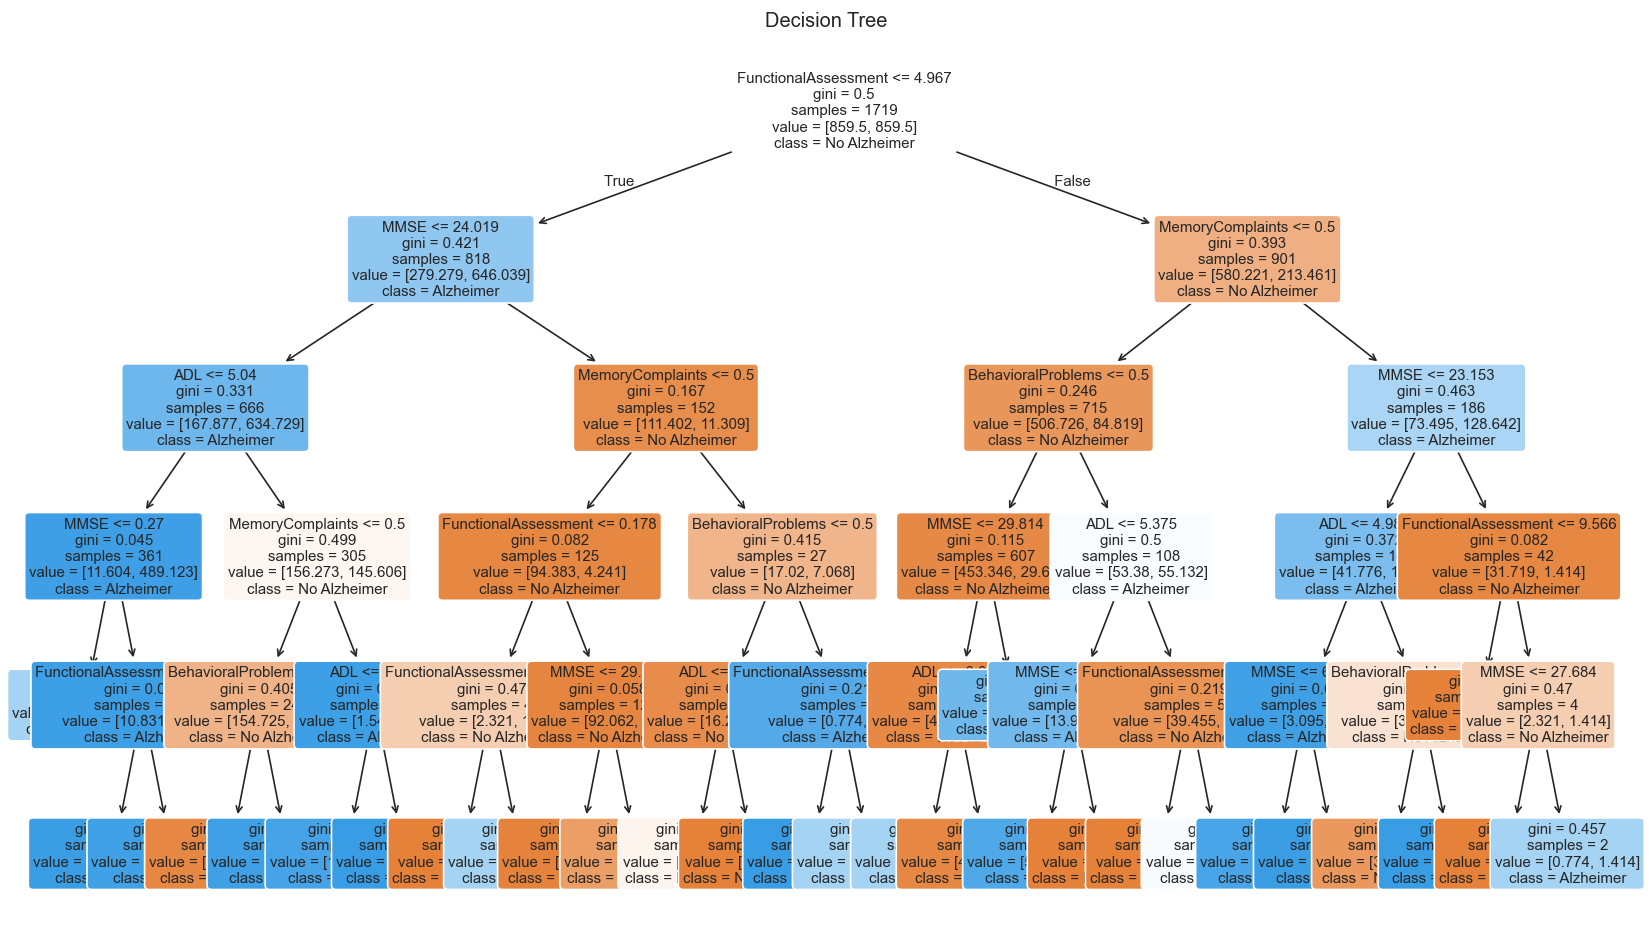

In [18]:


# Tree visualization 

plt.figure(figsize=(14,8))
plot_tree(
    dtree,
    feature_names=selected_features,
    class_names=["No Alzheimer", "Alzheimer"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()


In [19]:

# Decision path. 0 = first row.

client_index = 0

x_client = X_test.iloc[client_index:client_index+1].values  # 2D array
client_prob = dtree.predict_proba(x_client)[0,1]
client_pred = int(client_prob >= chosen_threshold)

print("\nClient index in test set:", client_index)
print("Client features:")
display(X_test.iloc[client_index:client_index+1])
print("Predicted probability of AD:", round(client_prob, 3))
print("Predicted label at chosen threshold:", client_pred)

# Walk the path
node_indicator = dtree.decision_path(x_client)
feature = dtree.tree_.feature
threshold = dtree.tree_.threshold

print("\nDecision path for the client:")
for node_id in node_indicator.indices:
    if feature[node_id] != -2:  # -2 means leaf
        fname = selected_features[feature[node_id]]
        thresh = threshold[node_id]
        value = x_client[0, feature[node_id]]
        direction = "<=" if value <= thresh else ">"
        print(f"  If {fname} {direction} {thresh:.3f} (client has {value:.3f})")



Client index in test set: 0
Client features:


C:\Users\julia\Desktop\Modules\Week7\project_w7\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,MemoryComplaints,BehavioralProblems,FunctionalAssessment,ADL,MMSE
451,0,0,1.273793,2.014531,13.957099


Predicted probability of AD: 0.989
Predicted label at chosen threshold: 1

Decision path for the client:
  If FunctionalAssessment <= 4.967 (client has 1.274)
  If MMSE <= 24.019 (client has 13.957)
  If ADL <= 5.040 (client has 2.015)
  If MMSE > 0.270 (client has 13.957)
  If FunctionalAssessment <= 2.766 (client has 1.274)


C:\Users\julia\Desktop\Modules\Week7\project_w7\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Insights

This decision‑tree model predicts an ADL impairment with overall discrimination (ROC AUC ~0.95) and strong precision (AP ~0.90). At the current cutoff it is very good at avoiding false alarms (specificity ~96%, only ~12 false positives) but it misses some true cases (sensitivity ~75%, about 54 false negatives). The predicted probabilities are reasonably well calibrated, so a 70% predicted risk means roughly a 70% chance in reality. The most informative inputs are functional assessment and IADL measures, with memory and behavioral factors adding value—exactly what clinicians expect.

These results seem trustworthy because they’re evaluated on a separate test set, multiple metrics agree and the important features and tree splits make clinical sense. Overall, the model is accurate, interpretable, and its risk scores can be used to guide screening or triage. The result with all parametters consided show a possible __False Positive__

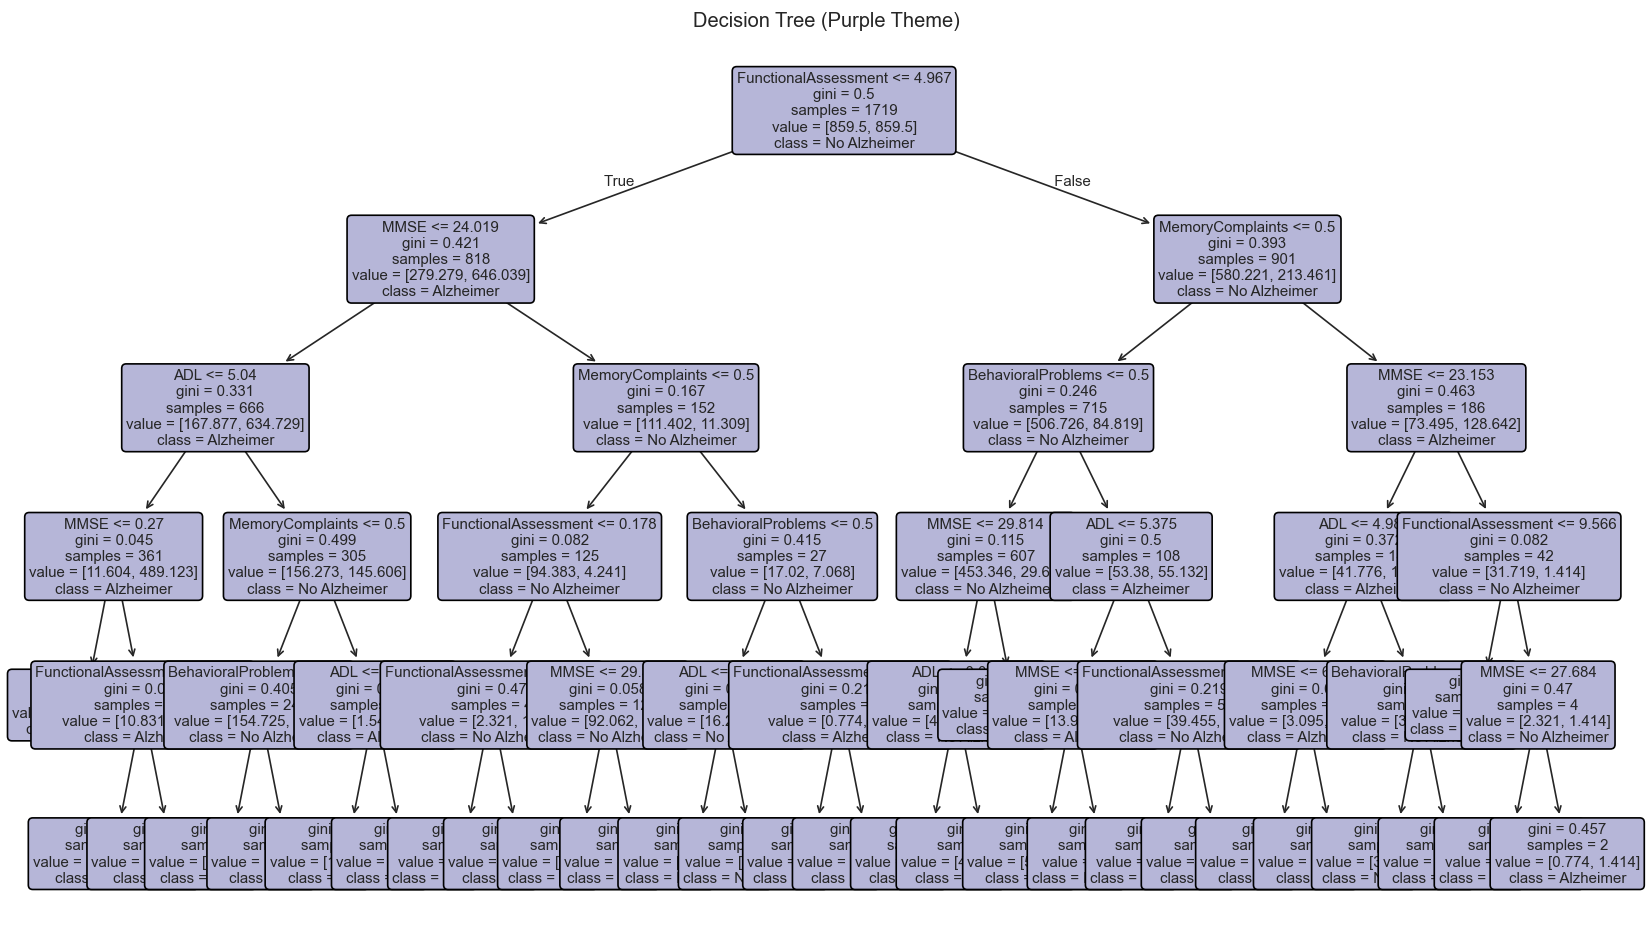

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib

# Use the new colormap API
cmap = matplotlib.colormaps["Purples"]

plt.figure(figsize=(14, 8))
artists = plot_tree(
    dtree,
    feature_names=selected_features,
    class_names=["No Alzheimer", "Alzheimer"],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=False,
    label='all',
    precision=3
)

# Recolor node boxes safely
for artist in artists:
    patch = artist.get_bbox_patch()
    if patch is not None:  # only modify nodes that have a box
        patch.set_facecolor(cmap(0.4))  # pick shade here (0-1)
        patch.set_edgecolor("black")    # optional: black border for clarity

plt.title("Decision Tree (Purple Theme)")
plt.tight_layout()
plt.show()